# 02 — Qualidade dos chats comerciais

Avaliação dos 2 chats comerciais (ChatGPT web e Claude.ai) usando dois ângulos:

1. **Árbitro humano nas 29 divergências** entre GPT e Opus (`chats_div_avaliado.xlsx`)
2. **Score do rubric unificado** (correção + foco) para todos os 300 chats
   (`analise_consolidada.xlsx`, filtrado em `tipo == "chat"`)

Como **não temos os 271 casos convergentes** das avaliações GPT/Opus para os chats
(só temos as 29 divergências), o `score` do rubric unificado vira a medida principal.

In [1]:
# Setup comum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}
PALETA_AVALIADOR = {'gpt': '#10A37F', 'opus': '#D97757', 'humano': '#8E44AD'}
PALETA_TIPO = {'api': '#2E86AB', 'chat': '#E74C3C'}
CORES_NOTA = {0.0: '#E74C3C', 0.5: '#F39C12', 1.0: '#2ECC71'}

# Detecta a pasta data/ automaticamente — tenta vários caminhos
def find_data_dir():
    candidatos = [Path('.'), Path('data'), Path('../data'), Path('../../data'),
                  Path('./data'), Path('../../../data')]
    for p in candidatos:
        if (p / 'df_avaliacoes.xlsx').exists():
            return p.resolve()
    raise FileNotFoundError(
        'Não encontrei df_avaliacoes.xlsx. Coloque os 5 arquivos .xlsx '
        'em ./data/, ../data/, ou no mesmo diretório do notebook, ou edite '
        'a variável DATA manualmente abaixo.'
    )

DATA = find_data_dir()
INTER = DATA.parent / 'output' / 'intermediarios'
INTER.mkdir(parents=True, exist_ok=True)
print(f'DATA  = {DATA}')
print(f'INTER = {INTER}')

DATA  = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/tcc_analise
INTER = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/output/intermediarios


## 1. Carregamento

In [2]:
CHAT_NAME_MAP = {'std_chatgpt': 'chatgpt', 'std_claude': 'claude_chat'}

df_uni = pd.read_excel(DATA / 'analise_consolidada.xlsx')
df_chat_div = pd.read_excel(DATA / 'chats_div_avaliado.xlsx')

# Normalizar nomes dos chats
df_chat_div['modelo'] = df_chat_div['modelo'].replace(CHAT_NAME_MAP)
df_chat_div = df_chat_div.rename(columns={
    'avaliação humana': 'avaliacao_humana',
    'modelo.1': 'modelo_correto',
})

df_chats = df_uni[df_uni['tipo'] == 'chat'].copy()
print(f'Chats no rubric unificado:  {len(df_chats)} linhas ({df_chats["modelo"].unique()})')
print(f'Divergências com árbitro:   {len(df_chat_div)} linhas')

Chats no rubric unificado:  300 linhas (<ArrowStringArray>
['chatgpt', 'claude_chat']
Length: 2, dtype: str)
Divergências com árbitro:   29 linhas


## 2. Distribuição do score nos 300 chats

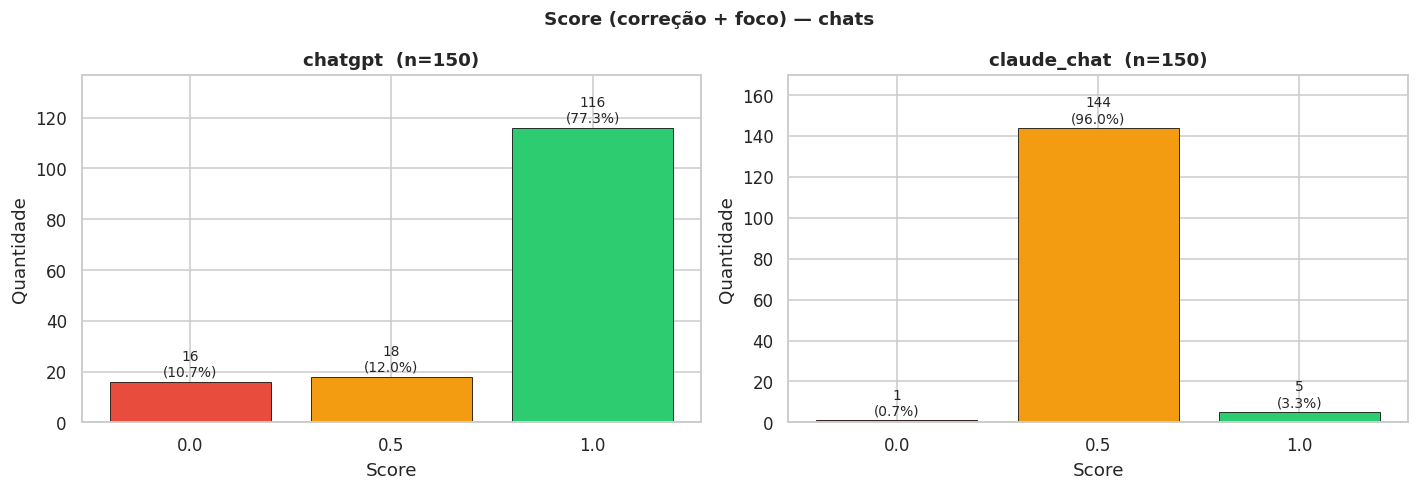


Resumo dos chats:
             score_medio  taxa_perfeita  taxa_parcial  taxa_errada    n
modelo                                                                 
chatgpt            0.833          0.773          0.12        0.107  150
claude_chat        0.513          0.033          0.96        0.007  150


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, m in zip(axes, ['chatgpt', 'claude_chat']):
    sub = df_chats[df_chats['modelo'] == m]
    cnt = sub['score'].value_counts().reindex([0.0, 0.5, 1.0], fill_value=0)
    bars = ax.bar(cnt.index.astype(str), cnt.values,
                  color=[CORES_NOTA[k] for k in cnt.index],
                  edgecolor='black', linewidth=0.5)
    ax.set_title(f'{m}  (n={len(sub)})')
    ax.set_xlabel('Score'); ax.set_ylabel('Quantidade')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1,
                f'{int(h)}\n({h/len(sub)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, cnt.max() * 1.18)
plt.suptitle('Score (correção + foco) — chats', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nResumo dos chats:')
print(df_chats.groupby('modelo').agg(
    score_medio=('score','mean'),
    taxa_perfeita=('score', lambda x: (x==1.0).mean()),
    taxa_parcial=('score', lambda x: (x==0.5).mean()),
    taxa_errada=('score', lambda x: (x==0.0).mean()),
    n=('score','count'),
).round(3))

## 3. Score por edital e categoria

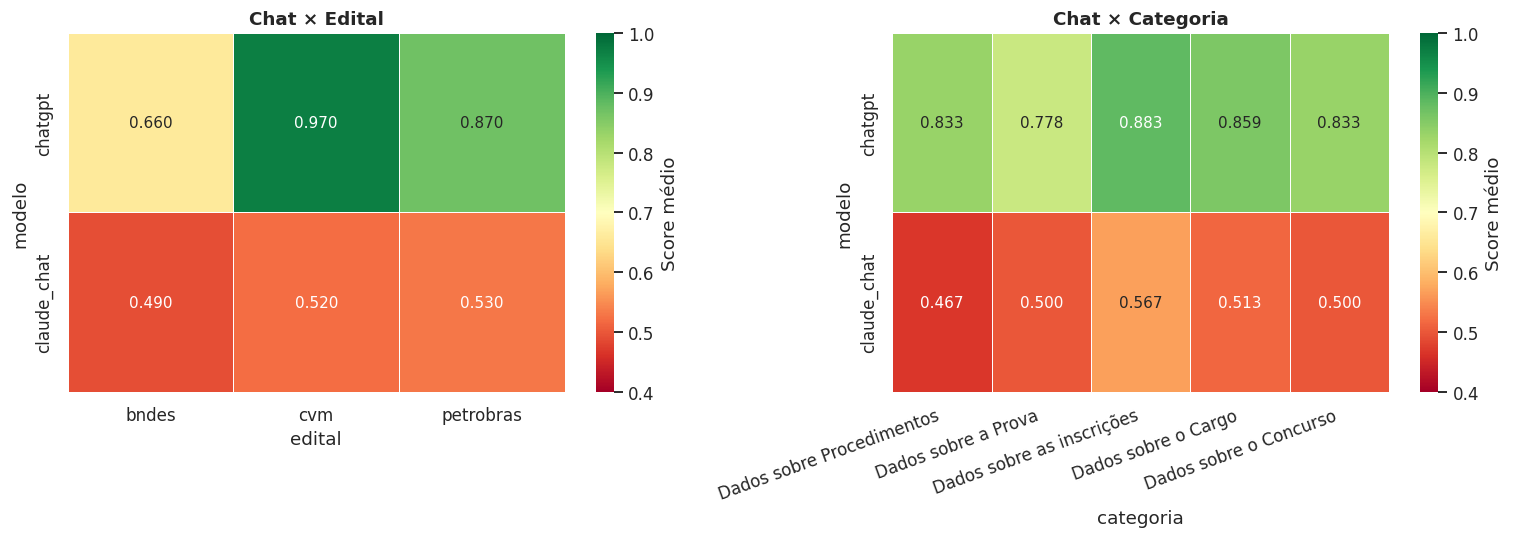

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
heat_ed = df_chats.pivot_table(index='modelo', columns='edital',
                                values='score', aggfunc='mean')
sns.heatmap(heat_ed, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
            cbar_kws={'label':'Score médio'}, linewidths=0.5, ax=axes[0])
axes[0].set_title('Chat × Edital')

heat_cat = df_chats.pivot_table(index='modelo', columns='categoria',
                                 values='score', aggfunc='mean')
sns.heatmap(heat_cat, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
            cbar_kws={'label':'Score médio'}, linewidths=0.5, ax=axes[1])
axes[1].set_title('Chat × Categoria')
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')
plt.tight_layout(); plt.show()

## 4. As 29 divergências dos chats — em quem o humano confiou?

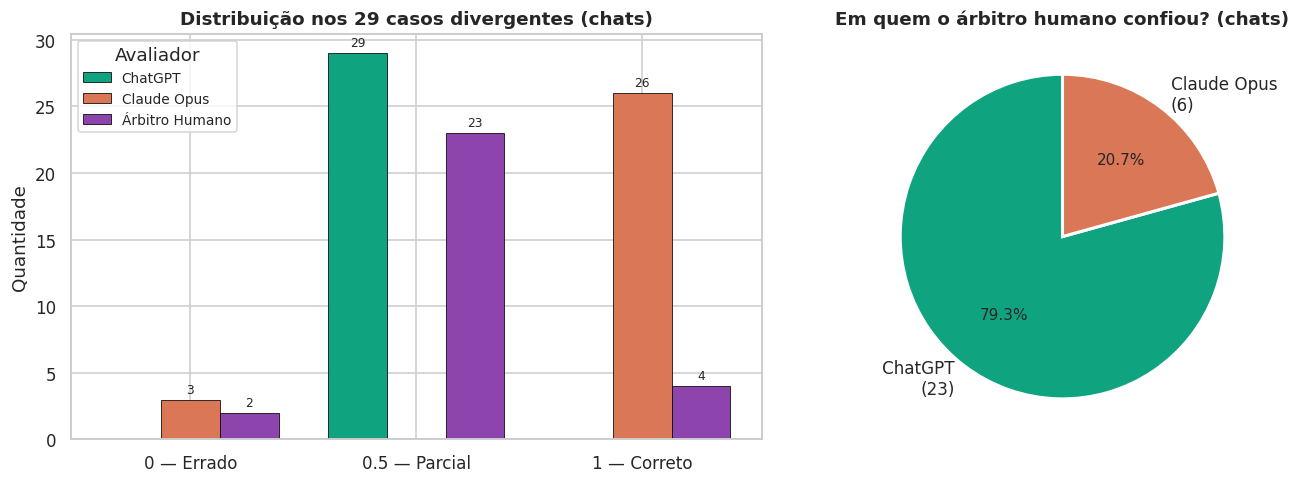


Divergências por chat:
modelo
chatgpt        11
claude_chat    18


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribuição GPT, Opus, Humano
notas = [0.0, 0.5, 1.0]; x = np.arange(len(notas)); w = 0.26
cols_av = {
    'ChatGPT':       ('avaliacao_gpt',   PALETA_AVALIADOR['gpt']),
    'Claude Opus':   ('avaliacao_opus',  PALETA_AVALIADOR['opus']),
    'Árbitro Humano':('avaliacao_humana', PALETA_AVALIADOR['humano']),
}
for i, (label, (col, cor)) in enumerate(cols_av.items()):
    cnt = df_chat_div[col].value_counts().reindex(notas, fill_value=0)
    bars = axes[0].bar(x + (i-1)*w, cnt.values, w, label=label, color=cor,
                       edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, cnt.values):
        if v > 0:
            axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, str(int(v)),
                         ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(['0 — Errado','0.5 — Parcial','1 — Correto'])
axes[0].set_ylabel('Quantidade')
axes[0].set_title(f'Distribuição nos {len(df_chat_div)} casos divergentes (chats)')
axes[0].legend(title='Avaliador', fontsize=9)

# Pizza
razao = df_chat_div['modelo_correto'].value_counts()
NOMES_JUIZ = {'gpt':'ChatGPT', 'opus':'Claude Opus'}
labels_pie = [f'{NOMES_JUIZ.get(k,k)}\n({v})' for k,v in razao.items()]
cores_r = [PALETA_AVALIADOR.get(k,'#BDC3C7') for k in razao.index]
axes[1].pie(razao.values, labels=labels_pie, colors=cores_r,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Em quem o árbitro humano confiou? (chats)')

plt.tight_layout(); plt.show()
print(f'\nDivergências por chat:')
print(df_chat_div.groupby('modelo').size().to_string())

## 5. Comparação com as 92 divergências da API

In [6]:
# Carrega o resumo da API direto dos arquivos brutos (sem depender de .pkl)
df_av_api = pd.read_excel(DATA / 'df_avaliacoes.xlsx')
df_div_api = pd.read_excel(DATA / 'divergentes_human_eval.xlsx')

df_div_api[['edital_h','modelo_h']] = df_div_api['pasta'].str.split('_', n=1, expand=True)
lookup = (df_div_api[['edital_h','modelo_h','id','Avaliação Humana','Modelo Correto']]
          .rename(columns={'edital_h':'edital','modelo_h':'modelo',
                           'Avaliação Humana':'avaliacao_humana',
                           'Modelo Correto':'modelo_correto'}))
df_av_api = df_av_api.merge(lookup, on=['edital','modelo','id'], how='left')

div_api = df_av_api[~df_av_api['convergencia']]
resumo_api = div_api['modelo_correto'].value_counts()
resumo_chat = df_chat_div['modelo_correto'].value_counts()

comp = pd.DataFrame({
    'API (n=92)':  [resumo_api.get('gpt',0),  resumo_api.get('opus',0)],
    'Chats (n=29)':[resumo_chat.get('gpt',0), resumo_chat.get('opus',0)],
}, index=['ChatGPT correto', 'Claude Opus correto'])
comp['% API'] = (comp['API (n=92)'] / comp['API (n=92)'].sum() * 100).round(1)
comp['% Chats'] = (comp['Chats (n=29)'] / comp['Chats (n=29)'].sum() * 100).round(1)
print('Em quem o humano confiou (API vs Chats):')
print(comp)
print()
print('Observação: em ambos os contextos, o GPT como juiz se mostra mais preciso')
print('que o Opus quando os dois discordam. Padrão consistente.')

Em quem o humano confiou (API vs Chats):
                     API (n=92)  Chats (n=29)  % API  % Chats
ChatGPT correto              63            23   68.5     79.3
Claude Opus correto          29             6   31.5     20.7

Observação: em ambos os contextos, o GPT como juiz se mostra mais preciso
que o Opus quando os dois discordam. Padrão consistente.


## 6. Ranking dos chats pelo score do rubric

In [7]:
ranking_chats = (df_chats.groupby(['modelo','provider'])
                 .agg(score_medio=('score','mean'),
                      taxa_perfeita=('score', lambda x: (x==1.0).mean()),
                      n=('score','count'))
                 .round(3).reset_index()
                 .sort_values('score_medio', ascending=False))
print(ranking_chats.to_string(index=False))

     modelo  provider  score_medio  taxa_perfeita   n
    chatgpt    openai        0.833          0.773 150
claude_chat anthropic        0.513          0.033 150


## 7. Resumo

- **chatgpt** tem score significativamente maior que **claude_chat** (~0.83 vs ~0.51)
- O padrão de confiança no árbitro humano é **idêntico** ao da API: ChatGPT como
  juiz acerta mais que Opus quando discordam (~80% vs ~20%)
- Sem os 271 casos convergentes, o método multi-juiz (notebook 1) não é replicável
  para os chats — por isso o `score` do rubric unificado é a medida primária aqui